# Optical Neural Network (ONN) on MNIST — Phase-Mask Classifier

Notebook version of `scripts/onn_mnist_example.py`.  We train a small **diffractive optical
neural network** (ONN) to classify MNIST digits using a stack of phase masks and free-space
propagation layers.

The final optical field is measured by a bank of 10 detector regions, and the integrated
intensities serve as class logits.  Training is end-to-end with JAX autodiff and Adam.

### Outline

0. **Imports**
1. **Paths and Parameters** 
2. **Helper Functions** (MNIST loader, detector bank, ONN builder).
3. **Setup**
4. **Loss Function and Optimization**.
5. **Evaluation** and report accuracy.
6. **Plot Results** for one test sample.


## 0  Imports


In [13]:
from __future__ import annotations

import urllib.request
from pathlib import Path

import jax
import jax.image
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from fouriax.example_utils import optimize_dataset_optical_module
from fouriax.optics import (
    Field,
    Grid,
    IntensitySensor,
    OpticalModule,
    PhaseMask,
    Spectrum,
    plan_propagation,
    plot_field_evolution,
)
%matplotlib inline


## 1  Paths and Parameters


In [14]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR = ARTIFACTS_DIR / "data"
MNIST_CACHE_PATH = DATA_DIR / "mnist.npz"
PLOT_PATH = ARTIFACTS_DIR / "onn_mnist_field_evolution.png"
SUMMARY_PATH = ARTIFACTS_DIR / "onn_mnist_summary.json"

DEVICE = "cpu"
SEED = 0
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.2
NUM_PHASE_LAYERS = 4
PHASE_MASK_DOWNSAMPLE = 4
NYQUIST_FACTOR = 1.0
DISTANCE_UM = 50.0
TRAIN_SAMPLES = 1000
TEST_SAMPLES = 100


## 2  Helper Functions


In [15]:
def load_mnist(cache_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if not cache_path.exists():
        print(f"Downloading MNIST to {cache_path} ...")
        urllib.request.urlretrieve(MNIST_URL, cache_path)

    with np.load(cache_path) as data:
        x_train = data["x_train"].astype(np.float32) / 255.0
        y_train = data["y_train"].astype(np.int32)
        x_test = data["x_test"].astype(np.float32) / 255.0
        y_test = data["y_test"].astype(np.int32)
    return x_train, y_train, x_test, y_test


def build_detector_bank(grid: Grid) -> jnp.ndarray:
    """Build 10 non-overlapping detector regions (2 rows x 5 cols)."""
    x_edges = np.linspace(0, grid.nx, 6, dtype=int)
    y_edges = np.linspace(0, grid.ny, 3, dtype=int)
    masks = np.zeros((10, grid.ny, grid.nx), dtype=np.float32)

    idx = 0
    for row in range(2):
        for col in range(5):
            x0, x1 = x_edges[col], x_edges[col + 1]
            y0, y1 = y_edges[row], y_edges[row + 1]
            masks[idx, y0:y1, x0:x1] = 1.0
            idx += 1
    return jnp.asarray(masks)


def resize_images_to_grid(images: np.ndarray, grid: Grid) -> np.ndarray:
    arr = jnp.asarray(images, dtype=jnp.float32)[..., None]
    resized = jax.image.resize(
        arr,
        shape=(arr.shape[0], grid.ny, grid.nx, 1),
        method="linear",
    )[..., 0]
    return np.asarray(resized, dtype=np.float32)


## 3  Setup


In [16]:
jax.config.update("jax_platform_name", DEVICE)
selected_device = jax.devices()[0]
jax.config.update("jax_default_device", selected_device)
print(
    "device="
    f"{selected_device.platform} kind={getattr(selected_device, 'device_kind', 'unknown')}"
)

input_grid = Grid.from_extent(nx=28, ny=28, dx_um=1.0, dy_um=1.0)
spectrum = Spectrum.from_scalar(1.55)
propagator = plan_propagation(
    mode="auto",
    grid=input_grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
    nyquist_factor=NYQUIST_FACTOR,
    min_padding_factor=2.0,
)
work_grid = propagator.precomputed_grid or input_grid
mask_nx = work_grid.nx // PHASE_MASK_DOWNSAMPLE
mask_ny = work_grid.ny // PHASE_MASK_DOWNSAMPLE
mask_grid = Grid.from_extent(
    nx=mask_nx,
    ny=mask_ny,
    dx_um=(work_grid.nx * work_grid.dx_um) / mask_nx,
    dy_um=(work_grid.ny * work_grid.dy_um) / mask_ny,
)
detector_masks = build_detector_bank(work_grid)
detector_sensor = IntensitySensor(detector_masks=detector_masks, sum_wavelengths=True)

def build_module(raw_params: jnp.ndarray) -> OpticalModule:
    layers = []
    for i in range(raw_params.shape[0]):
        upsampled_latent = jax.image.resize(
            raw_params[i],
            shape=(work_grid.ny, work_grid.nx),
            method="linear",
        )
        bounded_phase = 2.0 * jnp.pi * jax.nn.sigmoid(upsampled_latent)
        layers.append(PhaseMask(phase_map_rad=bounded_phase))
        layers.append(propagator)
    return OpticalModule(layers=tuple(layers), sensor=detector_sensor)

x_train, y_train, x_test, y_test = load_mnist(MNIST_CACHE_PATH)
x_train = x_train[:TRAIN_SAMPLES]
y_train = y_train[:TRAIN_SAMPLES]
x_test = x_test[:TEST_SAMPLES]
y_test = y_test[:TEST_SAMPLES]
x_train = resize_images_to_grid(x_train, work_grid)
x_test = resize_images_to_grid(x_test, work_grid)

key = jax.random.PRNGKey(SEED)
phase_params = 0.05 * jax.random.normal(
    key,
    (NUM_PHASE_LAYERS, mask_grid.ny, mask_grid.nx),
    dtype=jnp.float32,
)


device=cpu kind=cpu


## 4  Loss Function and Optimization


In [17]:
def logits_single(raw_params: jnp.ndarray, image_2d: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_params)
    field = Field(
        data=image_2d[None, :, :].astype(jnp.complex64),
        grid=work_grid,
        spectrum=spectrum,
    )
    return module.measure(field)

logits_batch = jax.vmap(logits_single, in_axes=(None, 0))

def batch_loss(
    params: jnp.ndarray, images: jnp.ndarray, labels: jnp.ndarray
) -> jnp.ndarray:
    logits = logits_batch(params, images)
    log_probs = logits - jax.scipy.special.logsumexp(logits, axis=1, keepdims=True)
    nll = -log_probs[jnp.arange(labels.shape[0]), labels]
    return jnp.mean(nll)

def batch_accuracy(params: jnp.ndarray, images: np.ndarray, labels: np.ndarray) -> float:
    logits = np.asarray(logits_batch(params, jnp.asarray(images)))
    pred = np.argmax(logits, axis=1)
    return float(np.mean(pred == labels))

optimizer = optax.adam(learning_rate=LEARNING_RATE)
train_data = (x_train, y_train)
val_data = (x_test, y_test)

def loss_fn(
    params: jnp.ndarray,
    batch: tuple[np.ndarray, np.ndarray],
) -> jnp.ndarray:
    xb_np, yb_np = batch
    xb = jnp.asarray(xb_np, dtype=jnp.float32)
    yb = jnp.asarray(yb_np, dtype=jnp.int32)
    return batch_loss(params, xb, yb)

result = optimize_dataset_optical_module(
    init_params=phase_params,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_data=train_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    val_data=val_data,
    seed=SEED + 1,
)


epoch=001 step=00015 train_loss=10.937522 val_loss=7.569944 [best]
epoch=002 step=00031 train_loss=3.504551 val_loss=3.413742 [best]
epoch=003 step=00047 train_loss=1.129414 val_loss=1.857428 [best]
epoch=004 step=00063 train_loss=0.696615 val_loss=1.276824 [best]
epoch=005 step=00079 train_loss=0.904268 val_loss=1.190848 [best]
epoch=006 step=00095 train_loss=0.343246 val_loss=0.982328 [best]
epoch=007 step=00111 train_loss=0.196215 val_loss=0.973360 [best]
epoch=008 step=00127 train_loss=0.302576 val_loss=0.955216 [best]
epoch=009 step=00143 train_loss=0.248126 val_loss=0.960267
epoch=010 step=00159 train_loss=0.228451 val_loss=0.960050


## 5  Evaluation


In [18]:
train_acc = batch_accuracy(result.params_result.best_params, x_train, y_train)
test_acc = batch_accuracy(result.params_result.best_params, x_test, y_test)
final_val_loss = (
    float(result.params_result.final_val_metrics["val_loss"])
    if result.params_result.final_val_metrics
    else float("nan")
)
print(
    f"final_train_acc={train_acc:.4f} final_test_acc={test_acc:.4f} "
    f"final_val_loss={final_val_loss:.4f}"
)

module = result.best_module
sample_idx = 0
test_image = jnp.asarray(x_test[sample_idx], dtype=jnp.float32)
sample_field = Field(
    data=test_image[None, :, :].astype(jnp.complex64),
    grid=work_grid,
    spectrum=spectrum,
)


final_train_acc=0.9660 final_test_acc=0.8000 final_val_loss=0.9600


## 6  Plot Results


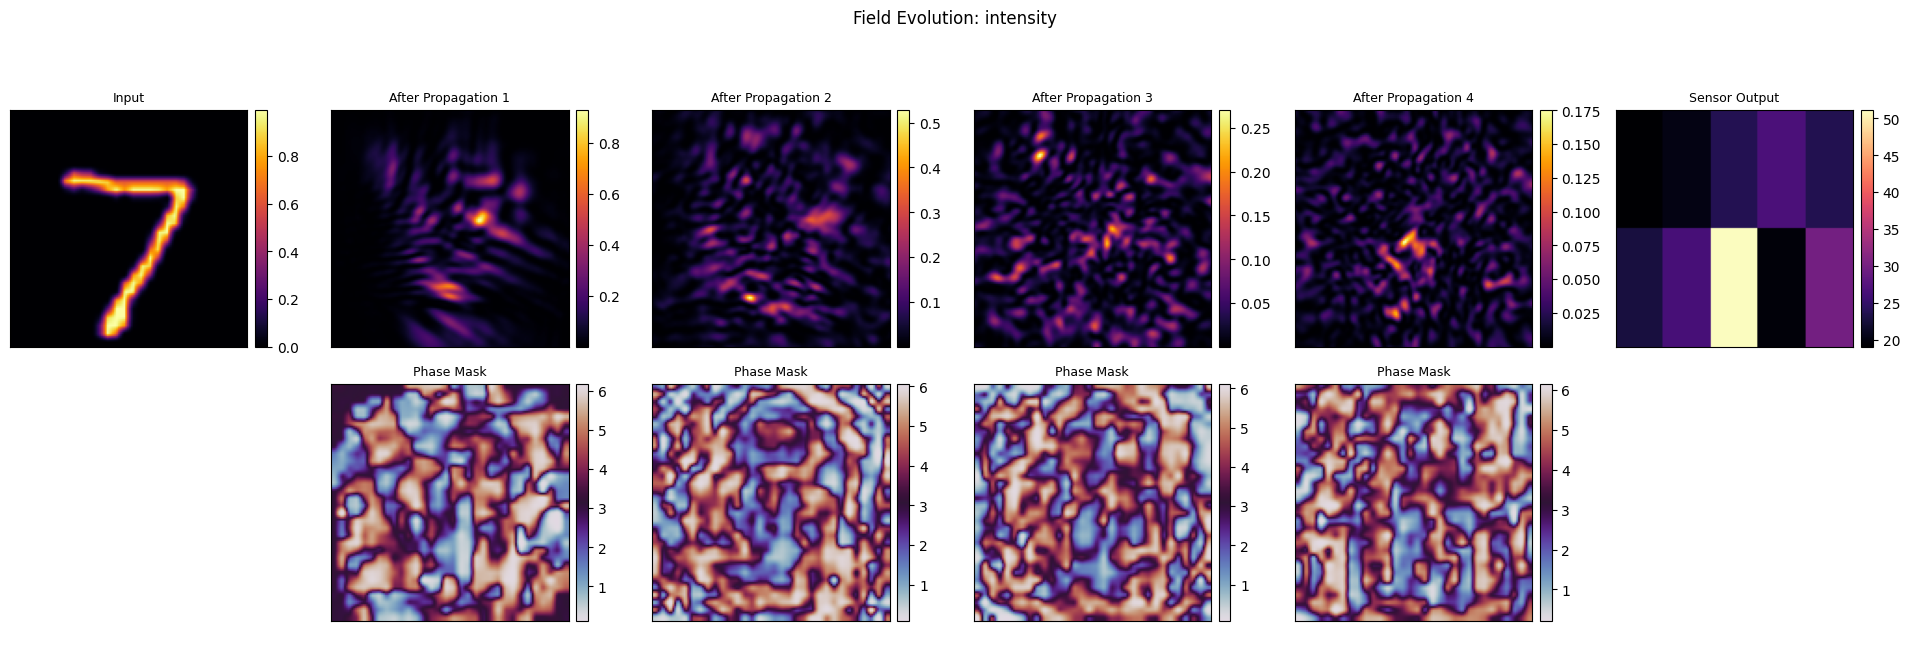

saved: artifacts/onn_mnist_field_evolution.png


In [19]:
fig_field, _ = plot_field_evolution(
    module=module,
    field_in=sample_field,
    mode="intensity",
    wavelength_idx=0,
    log_scale=False,
)
fig_field.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
fig_field.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"saved: {PLOT_PATH}")
